# Financial Trading with Python, 2nd Edition

Cordell L. Tanny, CFA, FRM, FDP

**Chapter 13: Algorithmic Trading Strategies**

Notebook 13.2: A Bollinger Band Mean-Reversion Trading System: Iteration 2

Version: 1.0

Last revised: 2026-05-31




---
## Introduction

In the previous iteration we built a complete mean-reversion system and then watched it fail in two specific ways. The signal was real: a deep close below the lower Bollinger band tended to revert, and the per-trade win rate confirmed it. What the system lacked was any way to manage a position once it was on. A name that entered and kept falling was held until it reverted, however far it fell and however long it took, and XLE falling forty percent over thirty-eight days during the COVID crash was the clearest case. Capital was also tied up in names that went nowhere, and the system traded often enough that costs alone cut its return by two thirds.

This iteration adds the two risk controls that target those flaws directly. A stop loss closes a position that falls a set percentage below its entry price, capping the damage from a name that does not revert. A time limit closes a position that has been held longer than a set number of trading days, releasing capital from a name that is neither reverting nor stopping out. Nothing else about the system changes: the universe, the bands, the entry signal, the stretch-score selection, and the twenty percent cap are all carried over unchanged, so any difference in the results is attributable to the risk layer and nothing else.

To make that comparison clean, we build both versions in the same notebook. The position logic is written once as a function with the stop and time limit as optional switches. Turning both off reproduces Iteration 1 exactly; turning them on gives us Iteration 2. We run the harness on both and read them side by side on the full metric set, with explicit attention to whether the controls reduced the trade count and improved the costed return, not just whether they cut the deep losers.

This notebook covers:

- Reusing the Iteration 1 universe, bands, entry signal, and stretch score without modification
- Writing the position loop as one function with stop loss and time limit as optional controls
- The three-trigger exit, checked in order each day: stop loss, then time limit, then mid-band reversion
- Generating both the no-stops and with-stops weight files from the same function, so the comparison is self-contained
- Backtesting the with-stops system and attributing every exit to the trigger that caused it
- Comparing Iteration 2 against Iteration 1 on the full metric set, trade count, and costed return

**Required Files:**
- `functions.py`
- `vectorbt_harness.py`

Please drag and drop them into the Colab instance.

## Section 1: Setup and Parameters

Before anything else, the notebook prepares its own environment. It pulls the two helper modules and the package list from the book's repository, so nothing has to be uploaded into the session by hand.

Package versions live in one file in the repository rather than being written into each notebook. When a pinned version stops resolving, and eventually it will, the fix is a single commit instead of an edit to every notebook in the chapter.

This cell also sets where price data comes from. The `USE_SAVED_PRICES` flag controls it:

- `True`, the default, reads prices from files stored in the repository. Every figure printed in this chapter came from those exact files, so your results will match the book.
- `False` downloads fresh data from Yahoo Finance. The notebook still runs end to end, but your numbers will differ from the printed ones.

The reason for the saved files is worth stating. Yahoo recomputes its entire adjusted price history whenever a new dividend or split is recorded, so a series downloaded today is not the series downloaded last month, and across a twenty-year window those revisions compound. Without fixed data, a reader whose numbers differ has no way to tell whether the cause is data drift at the source or a mistake in their own setup.

In [34]:
# --- Environment and data source -------------------------------------------
# Fetches the helper modules and the package list from the book repository,
# installs, and reports what actually landed. Nothing needs uploading by hand.

import os, sys, subprocess, importlib

# True  : read prices from the saved files, results match the book
# False : download fresh from Yahoo, results will differ
USE_SAVED_PRICES = True

REPO_RAW = ('https://raw.githubusercontent.com/PacktPublishing/'
            'Hands-on-Financial-Trading-with-Python-Second-Edition/main')
SCRIPTS_URL = f'{REPO_RAW}/FINAL/python_scripts'
DATA_URL    = f'{REPO_RAW}/FINAL/chapter13/data_files'
REQS_URL    = f'{REPO_RAW}/FINAL'

# Versions this chapter was written against. Used only for the report below.
TESTED = {'python': '3.13', 'numpy': '2.1.3', 'pandas': '2.2.3',
          'vectorbt': '0.28.5', 'pyarrow': '18.1.0', 'yfinance': '0.2.66'}


def fetch(fname, url_base):
    """Download a file into the session if it is not already there."""
    if os.path.exists(fname):
        print(f'  using local {fname}')
        return fname
    subprocess.run(['wget', '-q', f'{url_base}/{fname}'])
    if not os.path.exists(fname):
        raise FileNotFoundError(f'Could not fetch {fname} from {url_base}')
    print(f'  fetched {fname}')
    return fname


def fetch_data_file(fname):
    """Return a local path to a saved data file, downloading it once if needed."""
    return fetch(fname, DATA_URL)


# A pinned package with no wheel for your Python does not fail cleanly: pip
# tries to build from source and the runtime usually dies first. Checking here
# turns that into a readable message.
PY = f'{sys.version_info.major}.{sys.version_info.minor}'
if PY != TESTED['python']:
    print(f'NOTE: this chapter was tested on Python {TESTED["python"]}; you are on {PY}.')
    print('      If the install below hangs, a pinned package has no wheel for '
          'your Python.\n')

fetch('requirements-ch13.txt', REQS_URL)
fetch('functions.py', SCRIPTS_URL)
fetch('vectorbt_harness.py', SCRIPTS_URL)

# No -q here. A silent install that fails leaves you debugging an ImportError
# several cells later instead of reading the actual error now.
print('\nInstalling...')
!pip install -r requirements-ch13.txt 2>&1 | tail -6

print(f'\n{"package":<12}{"installed":<14}{"tested":<12}')
print('-' * 38)
print(f'{"python":<12}{PY + "." + str(sys.version_info.micro):<14}{TESTED["python"]:<12}')
for pkg in ['numpy', 'pandas', 'pyarrow', 'vectorbt', 'numba', 'yfinance']:
    try:
        v = importlib.import_module(pkg).__version__
    except Exception:
        v = 'not installed'
    flag = '' if TESTED.get(pkg) in (None, v) else '  <- differs'
    print(f'{pkg:<12}{v:<14}{TESTED.get(pkg, "-"):<12}{flag}')

print(f'\nUSE_SAVED_PRICES = {USE_SAVED_PRICES}'
      f'  ({"saved files, results match the book" if USE_SAVED_PRICES else "live download, results will differ"})')

  using local requirements-ch13.txt
  using local functions.py
  using local vectorbt_harness.py

Installing...

package     installed     tested      
--------------------------------------
python      3.13.15       3.13        
numpy       2.1.3         2.1.3       
pandas      2.2.3         2.2.3       
pyarrow     18.1.0        18.1.0      
vectorbt    0.28.5        0.28.5      
numba       0.61.2        -           
yfinance    0.2.66        0.2.66      

USE_SAVED_PRICES = True  (saved files, results match the book)


Every control for the system lives in the parameter block below, exactly as in Iteration 1, with two additions for the risk layer. `STOP_PCT` is the loss from the entry price at which a position is closed, and `TIME_LIMIT` is the maximum number of trading days a position is held before it is closed regardless of where its price sits. Both are set to the baseline we agreed on before sweeping: an eight percent stop and a twenty trading-day limit.

These two controls are written so they can be switched off. A `STOP_PCT` or `TIME_LIMIT` of `None` disables that trigger entirely, which is how we reproduce the Iteration 1 behaviour from the same code later in the notebook. The baseline values here describe the with-stops system; the no-stops run passes `None` for both.

Everything else is held at the Iteration 1 defaults. The band lookback is twenty days, the entry threshold is three sigma, the exit target is the mid band, and the system holds at most five positions at twenty percent each. We deliberately do not tune any of these here; the parameter sweeps belong in the robustness work that draws on the bad backtest forensics chapter.

In [35]:
# --- Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
from functions import calculate_performance_metrics

warnings.filterwarnings('ignore')
sns.set_theme()
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)

# --- Parameters (centralized: edit here to rerun the whole system) ---
# Signal and band parameters: identical to Iteration 1, carried over unchanged
# so the only difference between the two systems is the risk layer below.
LOOKBACK      = 20      # band moving-average and std window, in trading days
ENTRY_SIGMA   = 3.0     # standard deviations below the SMA for an entry signal
EXIT_BAND     = 'mid'   # exit target: 'mid' (the SMA) or 'upper' (SMA + sigma*std)
MAX_POSITIONS = 5       # at most this many concurrent positions
POSITION_CAP  = 0.20    # hard cap of capital per position (5 x 0.20 = fully invested)
WARMUP_BUFFER = 0       # extra days beyond LOOKBACK before an asset is eligible

# --- Risk-management parameters (NEW in Iteration 2) ---
# These are the entire difference from Iteration 1. Setting either to None
# disables that trigger, which is how we reproduce the Iteration 1 system
# from the same position-loop function later in the notebook.
STOP_PCT   = 0.08   # close a position down this fraction from its entry price (8%)
TIME_LIMIT = 20     # close a position after this many trading days held (bars, not calendar days)

STOP_LABEL = 'OFF' if STOP_PCT   is None else f'-{STOP_PCT:.0%}'
TIME_LABEL = 'OFF' if TIME_LIMIT is None else f'{TIME_LIMIT}d'

START_DATE = '2007-01-01'   # earliest data pull; eligibility grows from here
END_DATE   = '2026-05-31'

# --- The ETF universe: 50 funds, varied on purpose (unchanged from Iteration 1) ---
UNIVERSE = [
    # Equity: broad, style, sector, thematic
    'QQQ', 'VTI', 'VYM', 'IWM', 'SMDV', 'SPYG', 'IWF', 'VO', 'VBR', 'VOE',
    'SPGP', 'REGL', 'IWV', 'XLF', 'XLE', 'XLK', 'XLV', 'XLY', 'XLI', 'XLP',
    'XLU', 'XLC', 'SOXX', 'MOAT', 'ARKK', 'ARKG', 'ARKW', 'SDY', 'USMV', 'HDV',
    'DIA', 'FDN', 'VIG', 'FPX', 'ITB', 'ITA', 'DES', 'XMLV', 'SPY', 'QTUM',
    # High yield credit
    'HYG',
    # Metals, commodities, currency, miners
    'GLD', 'SLV', 'DBC', 'USO', 'PICK', 'UUP', 'GDX', 'GDXJ', 'DBA',
]

print(f"Universe size: {len(UNIVERSE)} ETFs")
print(f"Band: {LOOKBACK}-day SMA +/- {ENTRY_SIGMA} std of price")
print(f"Exit target: {EXIT_BAND} band | Max positions: {MAX_POSITIONS} | Cap: {POSITION_CAP:.0%}")
print(f"Risk layer: stop {STOP_LABEL} | time limit {TIME_LABEL}")
print(f"\nUniverse:\n{UNIVERSE}")

Universe size: 50 ETFs
Band: 20-day SMA +/- 3.0 std of price
Exit target: mid band | Max positions: 5 | Cap: 20%
Risk layer: stop -8% | time limit 20d

Universe:
['QQQ', 'VTI', 'VYM', 'IWM', 'SMDV', 'SPYG', 'IWF', 'VO', 'VBR', 'VOE', 'SPGP', 'REGL', 'IWV', 'XLF', 'XLE', 'XLK', 'XLV', 'XLY', 'XLI', 'XLP', 'XLU', 'XLC', 'SOXX', 'MOAT', 'ARKK', 'ARKG', 'ARKW', 'SDY', 'USMV', 'HDV', 'DIA', 'FDN', 'VIG', 'FPX', 'ITB', 'ITA', 'DES', 'XMLV', 'SPY', 'QTUM', 'HYG', 'GLD', 'SLV', 'DBC', 'USO', 'PICK', 'UUP', 'GDX', 'GDXJ', 'DBA']


The output confirms the fifty funds loaded and the parameters echoed back, with the new risk-layer line showing the baseline we set: an eight percent stop and a twenty trading-day limit. Every signal and sizing parameter matches Iteration 1, so the band, the three-sigma entry, the mid-band exit, and the twenty percent cap are all held constant. Only the stop and time limit are new, and printing them on their own line keeps a visible record of which risk settings produced any given run, which matters once the sweeps start changing them.

With the parameters fixed, the next step is identical to Iteration 1: pull the price history and build each fund's Bollinger band. That code is carried over unchanged, since the signal is not what we are changing here.

## Section 2: Downloading Prices and Computing the Bands

We load dividend-adjusted daily closes for the whole universe at once, from the saved file or from a live download depending on the flag set earlier. The saved file holds the same frame yfinance returns, every price field included, so everything downstream of this cell is identical either way. As with the harness, the adjusted close folds in splits and dividends so the price series is continuous through corporate actions, and any fund that did not yet exist on a given date simply has no price there, which is exactly the missing-data pattern the entry-on-warmup rule relies on.

The band for each fund is built from its own price history alone. The middle of the band is the twenty-day simple moving average of price. The upper and lower edges sit a fixed number of standard deviations above and below that average, using the standard deviation of price over the same twenty-day window. Two points of discipline matter here. The standard deviation is computed on price, not on returns, because the band measures how far the current price sits from its recent typical level in that price's own units. And both the average and the standard deviation use only data through the prior close, so the band a price is compared against never contains the price it is being tested for. That shift by one day is what keeps the signal free of lookahead, and we verify it explicitly in a later cell.

In [36]:
# --- Load adjusted daily closes for the universe ---
# Both branches produce the same frame: the full yfinance OHLCV panel with
# a two-level column index. Everything below this point is unchanged.
if USE_SAVED_PRICES:
    raw = pd.read_parquet(fetch_data_file('ch13_nb02_signal_prices.parquet'))
else:
    raw = yf.download(UNIVERSE, start=START_DATE, end=END_DATE, auto_adjust=True)
prices = raw['Close'].copy()

# Keep the universe column order (yfinance returns them alphabetically).
prices = prices[[t for t in UNIVERSE if t in prices.columns]]

# --- Compute the band components per asset ---
# All three use data through the PRIOR close (shift by 1) so the band a price
# is tested against never includes that same day's price. This is the
# lookahead guard; we spot-check it in Section 3.
sma = prices.rolling(LOOKBACK).mean().shift(1)
std = prices.rolling(LOOKBACK).std().shift(1)

lower_band = sma - ENTRY_SIGMA * std
upper_band = sma + ENTRY_SIGMA * std
# Mid band is just the SMA; named here for clarity at the exit stage.
mid_band = sma

print(f"Price matrix: {prices.shape[0]} trading days, {prices.shape[1]} assets")
print(f"Date range:   {prices.index.min().date()} to {prices.index.max().date()}")
print(f"\nFirst valid band date per asset (shows staggered warmup):")
first_valid = lower_band.notna().idxmax()
first_valid = first_valid.sort_values()
print(first_valid.to_string())

  using local ch13_nb02_signal_prices.parquet
Price matrix: 4882 trading days, 50 assets
Date range:   2007-01-03 to 2026-05-29

First valid band date per asset (shows staggered warmup):
Ticker
QQQ    2007-02-01
DIA    2007-02-01
FPX    2007-02-01
ITB    2007-02-01
SDY    2007-02-01
ITA    2007-02-01
DES    2007-02-01
SPY    2007-02-01
GLD    2007-02-01
SOXX   2007-02-01
SLV    2007-02-01
XLU    2007-02-01
XLP    2007-02-01
XLI    2007-02-01
XLY    2007-02-01
FDN    2007-02-01
XLV    2007-02-01
XLE    2007-02-01
XLF    2007-02-01
IWV    2007-02-01
DBC    2007-02-01
USO    2007-02-01
VOE    2007-02-01
VBR    2007-02-01
VO     2007-02-01
IWF    2007-02-01
SPYG   2007-02-01
GDX    2007-02-01
IWM    2007-02-01
VYM    2007-02-01
VTI    2007-02-01
XLK    2007-02-01
VIG    2007-02-01
DBA    2007-02-05
UUP    2007-03-29
HYG    2007-05-09
GDXJ   2009-12-10
HDV    2011-04-29
SPGP   2011-07-15
USMV   2011-11-17
PICK   2012-03-02
MOAT   2012-05-23
XMLV   2013-03-18
ARKW   2014-10-28
ARKG   2014-12

The download returned all fifty funds over roughly nineteen years, and the first-valid-band dates show exactly the staggered entry the system is built to handle. Thirty-three funds have a usable band by the start of February 2007, twenty trading days after the data begins, which is the warmup the twenty-day window requires. From there the universe fills out in waves: DBA and UUP join within weeks, HYG in May 2007, GDXJ at the end of 2009, a cluster of low-volatility and moat funds through 2011 and 2012, the ARK thematic funds in late 2014, and XLC and QTUM last in mid and late 2018. Until each of those dates the fund contributes no signal and is simply absent from the candidate pool, rather than being backfilled with invented history.

This is the entry-on-warmup rule working as intended, and it has a consequence worth keeping in mind when reading later results. The system has only about thirty-three names to choose from in its early years and the full fifty only from late 2018 onward, so the breadth of the cross-sectional ranking widens over time. A scarcity of signals in the early period is therefore expected behaviour, not a defect, and it is identical between the two iterations since the bands and universe are unchanged.

With the bands in place, we generate the entry signal and the stretch score that ranks competing entries, again unchanged from Iteration 1 so the only difference between the systems remains the risk layer.

## Section 3: The Entry Signal and the Stretch Score

The entry test is one comparison: has the fund closed below its lower band today? Because the band was built from data through the prior close, comparing today's close against it uses no same-day information in the band itself, which is the lookahead discipline we set up in the previous section and verify in a moment.

A simple yes or no is not enough, though, because on a turbulent day more than five funds can breach their lower bands at once, and the system can hold only five positions. We need a way to rank competing entries. For that we compute a stretch score: how many standard deviations below its moving average each fund has closed. A fund three and a half standard deviations below its average is more stretched, and a stronger mean-reversion candidate, than one barely past the three-sigma line. The score is the z-score of price against the same shifted average and standard deviation used for the band, so a more negative score means more stretched. When entries compete for a limited number of open slots, the most negative scores win.

We also run a deliberate lookahead spot-check here. We pick one fund and one date and recompute its band by hand from the twenty prior closes, then confirm it matches the shifted band used by the signal. This is the manual audit the chapter insists on for any rule that could hide a same-bar leak.

In [37]:
# --- Entry signal: did the close fall below the lower band? ---
below_lower = prices < lower_band

# --- Stretch score: z-score of price vs the shifted band stats ---
# More negative = further below the average = more stretched. Used only to
# rank competing entries when more than MAX_POSITIONS funds breach at once.
stretch = (prices - sma) / std

# --- Lookahead spot-check ---
# Recompute one band value by hand from the 20 closes PRIOR to a test date and
# confirm it equals the shifted SMA the signal uses. If these match, the band
# on a given day contains no information from that day.
test_ticker = 'SPY'
test_date = prices.index[300]                      # an arbitrary in-sample date
loc = prices.index.get_loc(test_date)

manual_window = prices[test_ticker].iloc[loc - LOOKBACK:loc]   # 20 prior closes
manual_sma = manual_window.mean()
used_sma = sma.loc[test_date, test_ticker]

print(f"Lookahead spot-check on {test_ticker} at {test_date.date()}:")
print(f"  Manual SMA of the 20 prior closes: {manual_sma:.4f}")
print(f"  SMA used by the signal (shifted):  {used_sma:.4f}")
print(f"  Match: {np.isclose(manual_sma, used_sma)}")

print(f"\nTotal lower-band breaches across all assets/days: {int(below_lower.sum().sum())}")
print(f"Days with at least one breach: {int(below_lower.any(axis=1).sum())}")
print(f"Days with MORE than {MAX_POSITIONS} simultaneous breaches: "
      f"{int((below_lower.sum(axis=1) > MAX_POSITIONS).sum())}")

Lookahead spot-check on SPY at 2008-03-13:
  Manual SMA of the 20 prior closes: 95.6646
  SMA used by the signal (shifted):  95.6646
  Match: True

Total lower-band breaches across all assets/days: 3919
Days with at least one breach: 874
Days with MORE than 5 simultaneous breaches: 182


The spot-check confirms the discipline we care about most. Recomputing SPY's average by hand from the twenty closes before March 13, 2008 gives exactly the value the signal used, which means the band a price is tested against contains no information from the day being tested. The signal is free of same-bar lookahead, and because this logic is carried over unchanged, it holds for both iterations.

The breach counts give a first sense of how the strict three-sigma entry behaves across the whole universe and history. Lower-band breaches happen 3,919 times in total, spread across 874 distinct trading days, so on most days at least one fund somewhere in the universe is stretched. On 182 of those days more than five funds breach at once, which is when the system genuinely has to arbitrate: more candidates than open slots, and the stretch score decides which five are most extended. That stretch score is the number of standard deviations a fund has closed below its moving average, measured against the same shifted twenty-day window the band uses, so a more negative score means more stretched. It is a ranking key among the day's breaches, not a normalized feature, and it inherits the band's rolling, prior-close construction.

These counts match Iteration 1 exactly, and that is by design rather than coincidence. Both notebooks pull the same universe over the same window and build the same bands, so the entire signal layer is identical between them. The only thing that changes in this iteration is what happens to a position after it is entered, which is the risk layer we build next.

## Section 4: The Position Loop with Stops and Time Limits

This is where Iteration 2 departs from Iteration 1. The signal and the selection are unchanged; what changes is the set of reasons a position can close. Iteration 1 had one exit, price reverting to the mid band. Here a held name has three triggers, checked in this order each day:

1. Stop loss: price has fallen far enough below the entry price.
2. Time limit: the position has been held too many trading days.
3. Mid-band reversion: price has recovered to the band, as in Iteration 1.

The first trigger that fires closes the position. When more than one would fire on the same day, the fixed precedence above decides, and the exit is attributed accordingly.

We write the logic once, as a function, with the stop and time limit as optional arguments:

- `None` for both disables those triggers and leaves only the mid-band exit, reproducing Iteration 1 exactly.
- The baseline values give Iteration 2.

Running both systems through the same code guarantees they differ only in the risk layer, and makes the later sweeps a matter of changing arguments, not rewriting the loop.

The function also carries more state than Iteration 1, which only tracked which funds were held. For each held fund it now records:

- The entry price, so the stop has a reference.
- The entry day, so the time limit can count the bars since.
- The trigger that closed it, so we can attribute every exit and answer the central question of this iteration: which control did the work.

In [38]:
def run_position_loop(prices, below_lower, stretch, mid_band, upper_band,
                      max_positions, position_cap, exit_band_choice,
                      stop_pct=None, time_limit=None):
    """
    Walk the universe forward one day at a time and produce a daily weights
    frame, holding at most `max_positions` names under a hard `position_cap`.

    This is the single source of truth for BOTH iterations:
      - stop_pct=None, time_limit=None  -> Iteration 1 (mid-band exit only)
      - stop_pct, time_limit set        -> Iteration 2 (three-trigger exit)

    The loop is stateful because whether a fund is a valid entry today depends
    on what is already held today, and which slots are open depends on what
    exited today. That day-to-day dependency cannot be vectorized, so we step
    through the dates in order.

    EXIT PRECEDENCE (checked per held name, each day, in this exact order):
      1. Stop loss : today's close <= entry_price * (1 - stop_pct)
      2. Time limit: bars held >= time_limit
      3. Mid/upper : today's close >= the exit band
    The first trigger that fires closes the position, and the position is
    tagged with that trigger so we can attribute exits afterward.

    Parameters
    ----------
    prices        : DataFrame  daily adjusted closes, dates x tickers
    below_lower   : DataFrame  bool, True where close < lower band (the signal)
    stretch       : DataFrame  ranking key: sigma below the mean (more negative = more stretched)
    mid_band      : DataFrame  the SMA; the mid-band exit level
    upper_band    : DataFrame  SMA + sigma*std; the upper-band exit level
    max_positions : int        max concurrent holdings
    position_cap  : float      weight per held name
    exit_band_choice : str     'mid' or 'upper'; which band is the reversion exit
    stop_pct      : float|None  stop distance below entry price; None disables the stop
    time_limit    : int|None    max bars held before forced exit; None disables the limit

    Returns
    -------
    weights_daily : DataFrame   full daily weights (dates x tickers), 0 where flat
    exit_log      : DataFrame   one row per closed position, with the exit reason
    """
    # Pick the reversion exit band once, up front, rather than per-iteration.
    # This means that you could change this if you prefer the uppere band to trigger the sell.
    exit_band = mid_band if exit_band_choice == 'mid' else upper_band

    dates = prices.index
    tickers = list(prices.columns)

    # State carried day to day. For each held name we store the two things the
    # new triggers need that Iteration 1 did not track:
    #   'entry_price' -> the close on the signal day, the stop's reference price
    #   'entry_loc'   -> the integer index of the entry date, to count bars held
    # (Iteration 1's state was just a set of tickers; this is the key change.)
    held = {}                       # ticker -> {'entry_price', 'entry_loc'}

    # Outputs we build as we walk forward.
    weights_daily = pd.DataFrame(0.0, index=dates, columns=tickers)
    exit_records = []               # collected into a DataFrame at the end

    for i, today in enumerate(dates):
        # ---- 1. EXITS (always processed before entries) ----
        # We decide each held name's fate using ONLY today's close and the
        # state recorded at entry, so nothing here looks ahead.
        to_exit = []                # (ticker, reason) pairs closing today
        for tk, pos in held.items():
            px = prices.loc[today, tk]
            if pd.isna(px):
                # No price today (e.g. a halt); leave the position untouched.
                continue

            reason = None

            # --- Trigger 1: stop loss (highest precedence) ---
            # Measured against the ENTRY price (the signal-day close), checked
            # on closing prices only, no intraday. This is the control aimed
            # squarely at the XLE-type position that keeps falling after entry.
            if stop_pct is not None:
                stop_level = pos['entry_price'] * (1 - stop_pct)
                if px <= stop_level:
                    reason = 'stop'

            # --- Trigger 2: time limit (only if the stop did not fire) ---
            # Counted in BARS (trading days) since entry, not calendar days,
            # to stay on the same axis as the rest of the pipeline. Frees
            # capital from a name that neither reverts nor stops out.
            if reason is None and time_limit is not None:
                bars_held = i - pos['entry_loc']
                if bars_held >= time_limit:
                    reason = 'time'

            # --- Trigger 3: mid/upper-band reversion (the Iteration 1 exit) ---
            # The original payoff: price has recovered to the exit band.
            if reason is None:
                ex_level = exit_band.loc[today, tk]
                if pd.notna(ex_level) and px >= ex_level:
                    reason = 'band'

            if reason is not None:
                to_exit.append((tk, reason))

        # Apply the exits and log each one with its attributed trigger and the
        # realized return from the recorded entry price (for diagnostics later).
        for tk, reason in to_exit:
            pos = held.pop(tk)
            exit_records.append({
                'Ticker': tk,
                'Entry Date': dates[pos['entry_loc']],
                'Exit Date': today,
                'Bars Held': i - pos['entry_loc'],
                'Entry Price': pos['entry_price'],
                'Exit Price': prices.loc[today, tk],
                'Return': prices.loc[today, tk] / pos['entry_price'] - 1,
                'Exit Reason': reason,
            })

        # ---- 2. ENTRIES (fill any freed or still-open slots) ----
        open_slots = max_positions - len(held)
        if open_slots > 0:
            row_below = below_lower.loc[today]
            # Candidates: below the lower band today, not already held, with a
            # valid stretch score. A held name is never re-bought; only an
            # exit can close it, and re-entry requires a fresh breach later.
            candidates = [tk for tk in tickers
                          if tk not in held
                          and bool(row_below.get(tk, False))
                          and pd.notna(stretch.loc[today, tk])]
            # Rank by stretch score, most negative (most stretched) first.
            candidates.sort(key=lambda tk: stretch.loc[today, tk])
            for tk in candidates[:open_slots]:
                # Record entry state. The entry price is TODAY's close, the
                # same close the entry decision is made on and the anchor the
                # stop measures against. The harness fills the next bar with
                # costs, but the strategy layer uses the price it actually saw.
                held[tk] = {'entry_price': prices.loc[today, tk],
                            'entry_loc': i}

        # ---- 3. RECORD today's weights from the held set ----
        for tk in held:
            weights_daily.loc[today, tk] = position_cap

    exit_log = pd.DataFrame(exit_records)
    return weights_daily, exit_log


# Quick sanity check on the function before we use it in anger: run the
# WITH-STOPS (Iteration 2 baseline) configuration and report the shape and
# how many exits each trigger produced. The full weight files come next.
weights_i2, exit_log_i2 = run_position_loop(
    prices, below_lower, stretch, mid_band, upper_band,
    max_positions=MAX_POSITIONS, position_cap=POSITION_CAP,
    exit_band_choice=EXIT_BAND, stop_pct=STOP_PCT, time_limit=TIME_LIMIT,
)

print(f"Iteration 2 (stop {STOP_LABEL}, time {TIME_LABEL}) position loop complete.")
print(f"Daily weights shape: {weights_i2.shape}")
print(f"Total positions closed: {len(exit_log_i2)}")
print(f"\nExits by trigger:")
print(exit_log_i2['Exit Reason'].value_counts().to_string())
print(f"\nMean return by exit reason:")
print(exit_log_i2.groupby('Exit Reason')['Return'].mean().apply(lambda x: f"{x:+.2%}").to_string())

Iteration 2 (stop -8%, time 20d) position loop complete.
Daily weights shape: (4882, 50)
Total positions closed: 841

Exits by trigger:
Exit Reason
band    632
stop    125
time     84

Mean return by exit reason:
Exit Reason
band    +3.16%
stop    -9.97%
time    -3.26%


The exit attribution shows each trigger doing the job it was added for:

- Band exits, 632 of them, remain the system's bread and butter and the only profitable exit on average, at +3.16%. This is the original mean-reversion payoff, a position closed because price recovered to the band.
- Stop exits, 125, average -9.97%, just past the eight percent stop level. These are the XLE-type positions the stop is built to cut: names that kept falling after entry and would otherwise have been held open-ended. The average sits slightly below the stop because the trigger fires on the first close at or beyond the level, and a gap-down day clears it by more than eight percent.
- Time exits, 84, average -3.26%. These are positions that neither reverted nor fell far enough to stop out, the capital-stuck names the time limit is meant to release. The modest average loss is the point: they were going nowhere, and the limit frees the slot rather than waiting indefinitely.

Two things stand out. First, the stop and time triggers together account for 209 of 841 exits, about a quarter, so the risk layer is doing meaningful work rather than rarely firing. Second, both new triggers carry negative average returns while the band exit stays positive, which is the signature of risk management working as intended: it is closing the losers early, not interfering with the winners that revert on their own. Whether that improves the system once costs and the full metric set are considered is the question the backtest answers next, since cutting losers early also realizes losses that an open-ended hold might have recovered.

## Section 5: Building Both Weight Files

To compare the two systems fairly, we generate both weight files here from the same function, so a reader runs this notebook top to bottom without needing anything saved from Iteration 1. We call the loop twice:

- No-stops: both triggers set to `None`, which reproduces the Iteration 1 system exactly.
- With-stops: the baseline stop and time limit, which is Iteration 2.

Each call returns a full daily weights frame. The harness expects the sparse, event-driven form: one row per date on which the held set actually changed, since a day where nothing was bought or sold needs no row. We apply that same reduction to both frames and save each to its own CSV. The two files are then directly comparable, having been produced by identical code under identical settings apart from the risk layer.

In [39]:
def to_sparse_weights(weights_daily):
    """
    Reduce a full daily weights frame to the sparse, event-driven form the
    harness consumes: keep only the rows where the held set changed from the
    day before, since those are the only days a trade actually happens.

    A row is therefore a trade date; the position drifts unchanged between
    rows. This matches the convention used across the chapter's strategy files.
    """
    # A trade happens only when today's weights differ from yesterday's.
    # The first invested day counts as a change (from all-cash to a position).
    changed = (weights_daily != weights_daily.shift(1)).any(axis=1)
    sparse = weights_daily[changed].copy()

    # Trim any all-zero rows before the first position ever opens, but keep a
    # later zero row, which represents a genuine trade back to all-cash.
    first_invest_idx = weights_daily.any(axis=1).idxmax()
    sparse = sparse.loc[first_invest_idx:]
    return sparse


# --- Run 1: NO STOPS -> reproduces Iteration 1 exactly ---
# Both risk triggers off, so the only exit is mid-band reversion. This is the
# baseline we compare against, regenerated here so the notebook is self-contained.
weights_i1_daily, exit_log_i1 = run_position_loop(
    prices, below_lower, stretch, mid_band, upper_band,
    max_positions=MAX_POSITIONS, position_cap=POSITION_CAP,
    exit_band_choice=EXIT_BAND, stop_pct=None, time_limit=None,
)

# --- Run 2: WITH STOPS -> Iteration 2 baseline ---
# (Already computed in Section 4 as weights_i2/exit_log_i2; recomputed here so
# this cell stands on its own and both files are produced together.)
weights_i2_daily, exit_log_i2 = run_position_loop(
    prices, below_lower, stretch, mid_band, upper_band,
    max_positions=MAX_POSITIONS, position_cap=POSITION_CAP,
    exit_band_choice=EXIT_BAND, stop_pct=STOP_PCT, time_limit=TIME_LIMIT,
)

# --- Reduce both to sparse form and save ---
weights_i1_sparse = to_sparse_weights(weights_i1_daily)
weights_i2_sparse = to_sparse_weights(weights_i2_daily)

i1_file = 'bollinger_I1_weights.csv'
i2_file = 'bollinger_I2_weights.csv'
weights_i1_sparse.to_csv(i1_file)
weights_i2_sparse.to_csv(i2_file)

print(f"No-stops (Iteration 1): {len(weights_i1_sparse)} trade rows -> {i1_file}")
print(f"With-stops (Iteration 2): {len(weights_i2_sparse)} trade rows -> {i2_file}")
print(f"\nTrade-row difference (I2 - I1): {len(weights_i2_sparse) - len(weights_i1_sparse):+d}")

No-stops (Iteration 1): 922 trade rows -> bollinger_I1_weights.csv
With-stops (Iteration 2): 1017 trade rows -> bollinger_I2_weights.csv

Trade-row difference (I2 - I1): +95


Two results matter here. First, the no-stops run reproduces Iteration 1 exactly at 922 trade rows, which confirms that turning both triggers off recovers the original system bit for bit. The comparison that follows is therefore clean: the two files differ only in the risk layer.

Second, and against the intuition the iteration plan started with, the risk layer added trades rather than removing them. Iteration 2 has 1,017 trade rows, 95 more than Iteration 1. The reason is structural: a stop or time exit closes a position earlier than reversion would have, which frees a slot, and a freed slot tends to get refilled on the next breach. Cutting a position short does not end the system's trading, it recycles the capital into another position sooner. So the stop and time limit, whatever else they do, are not reducing overtrading on their own. They trade more often, not less.

This sharpens the question for the backtest. The case for the risk layer cannot rest on lower turnover, because turnover went up. It has to rest on the quality of what it cut: if the stop and time exits removed deep losers cheaply enough that the costed return improved despite the higher trade count, the layer earns its place. If the extra trading and the realized stop losses together drag the costed return down, it does not. The next section runs both files through the harness to settle it.

## Section 6: Backtesting the System

The weights file is the entire interface between the strategy and the backtest. The chapter harness, imported here as a module, does the rest: it takes adjusted prices for the tickers in the file, aligns them, runs the trades at each dated row with whole shares and realistic costs, and scores the result against a benchmark on monthly returns. Because every strategy in the chapter calls the same harness with the same settings, the numbers here are directly comparable to Iteration 1 and to the other systems in the chapter.

We run the Iteration 2 file first and read it on its own terms. As before, SPY is the benchmark for reference only; a small, often partly-invested mean-reversion book is not built to match a fully-invested index on total return. What matters is the risk-adjusted picture and, this time, what the risk layer did to the costed return given that it raised the trade count. The direct side-by-side against Iteration 1 follows in the next section.

When the saved-price flag is on we hand the harness two frames: the prices for the traded tickers and the benchmark prices. Both are needed. The benchmark's first available day helps set where the backtest window starts, so leaving the benchmark to a live download would let the comparison window move even with the strategy prices fixed. The same two frames are reused for every harness call in this notebook, including the parameter sweep, so each result is scored on identical prices.

In [40]:
# --- Backtest the Iteration 2 (with-stops) system via the chapter harness ---
# Same call signature and settings as Iteration 1, pointed at the I2 weights
# file, so the only difference in the result is the risk layer. The harness
# runs both an uncosted and a costed portfolio; the costed one is what a real
# account would have earned and the column we anchor on.
from vectorbt_harness import run_backtest

if USE_SAVED_PRICES:
    # Loaded once here and reused by every harness call below, including the
    # parameter sweep. The saved frame is wider than this strategy needs; the
    # harness trims it to the window the weights file implies.
    bt_prices = pd.read_parquet(fetch_data_file('ch13_nb02_backtest_prices.parquet'))
    bm_prices = pd.read_parquet(
        fetch_data_file('ch13_nb02_benchmark_prices.parquet')).iloc[:, 0]
else:
    bt_prices = None    # None means the harness downloads, as it always did
    bm_prices = None

result_i2 = run_backtest(
    i2_file,
    benchmark='SPY',
    fees=0.0010,        # 10 bps commission on the run with costs applied
    slippage=0.0005,    # 5 bps slippage on the run with costs applied
    init_cash=10_000,
    periods_per_year=12,
    prices=bt_prices,
    bench_prices=bm_prices,
)

  using local ch13_nb02_backtest_prices.parquet
  using local ch13_nb02_benchmark_prices.parquet
Using saved prices (no download).
  Saved file covers:  2007-01-03 to 2026-06-29
  Window taken:       2007-02-27 to 2026-06-01  (4846 rows)
Using saved benchmark prices for SPY (no download).
Backtest start: 2007-02-27
Backtest end:   2026-06-01
Trading days:   4846
Trades in window: 1017

Harness evaluation (monthly metrics)
                         Strategy No Cost Strategy w/ Costs SPY Buy & Hold
Total Return                      119.13%            34.59%        675.50%
Ann. Return (CAGR)                  4.12%             1.54%         11.13%
Ann. Volatility                    10.69%            10.68%         15.47%
Downside Deviation                  7.28%             7.68%         10.13%
Max Drawdown                      -30.13%           -31.24%        -50.78%
Max DD Duration (months)               96               115             52
Ulcer Index                         9.664        

The risk layer did not help. Read against Iteration 1's costed results, Iteration 2 is worse on nearly every measure that matters:

- Costed total return fell to 34.63%, from Iteration 1's 39%, and costed CAGR slipped to 1.54% from 1.7%.
- Monthly win rate dropped to 61.9%, from 68.5%. Cutting positions early turned would-be winners into realized losers.
- The costed profit factor is 1.18 and the costed Sharpe is 0.144, both thin, and the Information Ratio against SPY is more negative than Iteration 1's.
- Max drawdown improved, but only from -33% to -31.26%, and the drawdown duration got longer, 115 days costed versus Iteration 1's shorter underwater stretch.

The mechanism is visible in the exit attribution from Section 4. The stop fired 125 times at an average -9.97%, and the time limit 84 times at -3.26%. Some of those were genuine XLE-type losers the stop was built to cut. But many were positions that had fallen below the stop and would have reverted given the open-ended hold Iteration 1 allowed. The stop converted those paper losses into realized ones and then paid to re-enter elsewhere, which is why the trade count rose by 95 even as the system aimed to be more disciplined.

This is the central lesson of the iteration, and it runs against the intuition that risk management must improve a system. A stop loss is not free. On a mean-reversion strategy, where the edge comes precisely from buying things that have fallen and waiting for them to recover, a stop fights the edge directly: it sells the deeply stretched positions that are most likely to revert. The drawdown relief is real but small, and it was bought with lower return, a lower win rate, and higher turnover. Whether that is a trade worth making is exactly the kind of judgment the full metric set forces, and here the answer is that the naive Iteration 1 was the better system on every axis except a marginal drawdown improvement.

## Section 7: Why the Stop Fights the Edge

The metric table says the risk layer hurt; the trades say why. A mean-reversion system earns its return by buying names that have fallen far below their average and waiting for the snap back. A stop loss sells exactly those names when they fall a little further, which is often the moment just before they revert. To see this directly, we trace two positions the system actually held:

- A winner Iteration 1 captured in full, which the Iteration 2 stop would have cut before it recovered.
- A loser the stop cut early, the XLE-type case (from iteration 1) the risk layer is built for.

The contrast is the whole argument. The stop cannot tell the two apart at the moment it fires, because both look identical going down: a stretched position falling further. That is the structural problem with a stop on a mean-reversion book, and it is why the drawdown relief came at the cost of so many recovered winners.

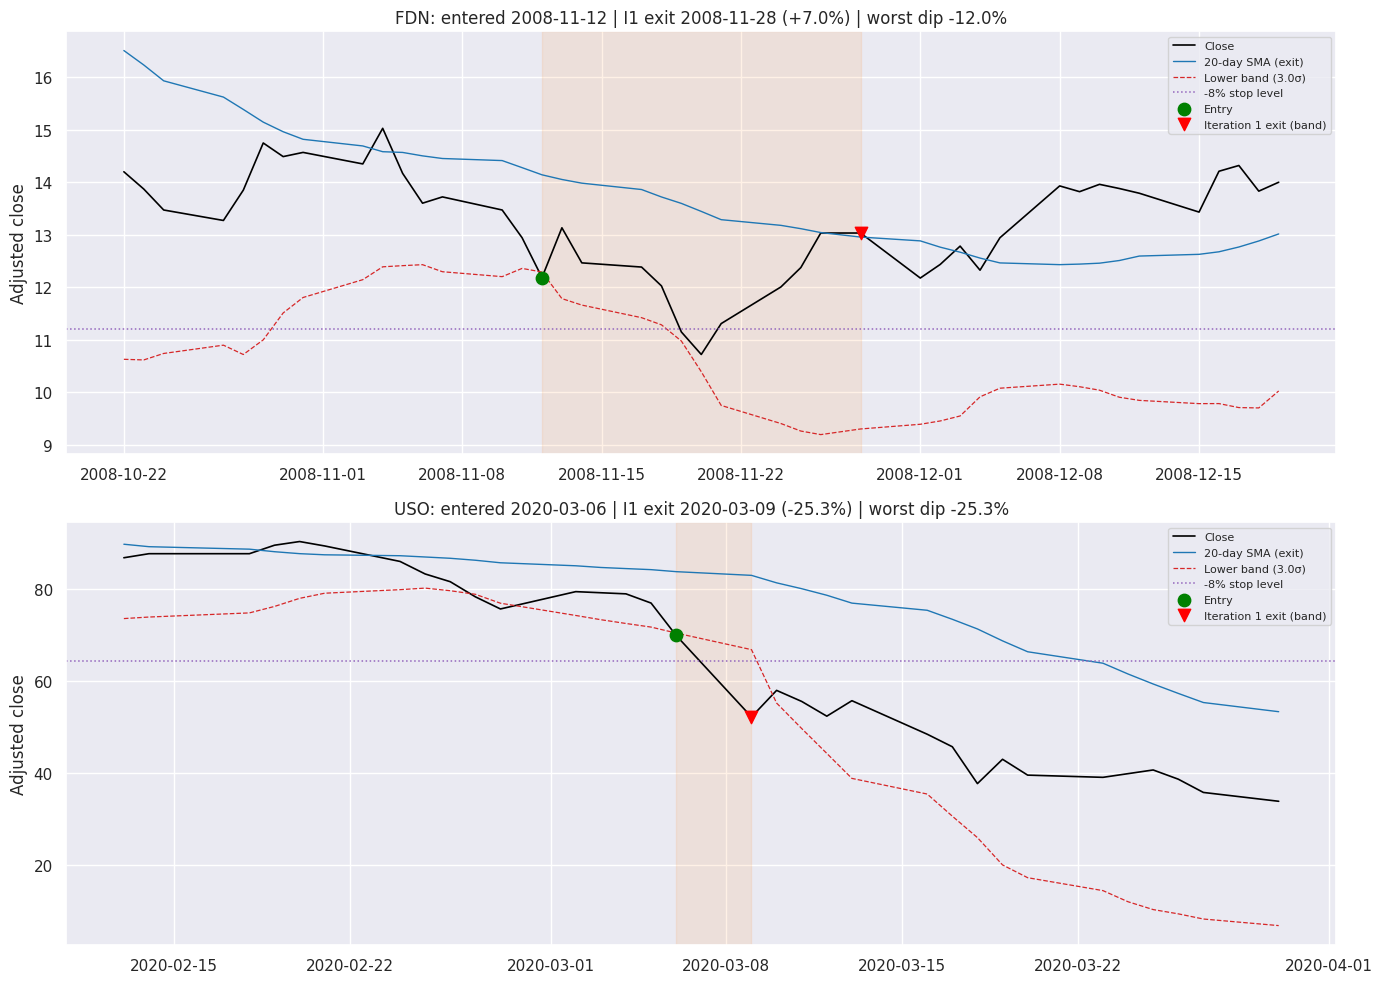

In [41]:
# --- Trace the two trades that show the stop fighting the edge ---
# Left case  (FDN, Nov 2008): an Iteration 1 WINNER. It fell to about -12%
#   mid-hold, past the -8% stop, then reverted to +7%. Iteration 2 stops it
#   out at the bottom and never sees the recovery.
# Right case (USO, Mar 2020): a genuine LOSER. It collapsed ~25% in days
#   during the oil crash. Here the stop helps, cutting the loss early.
# Same entry rule, same falling-through-the-band look, opposite outcome.

def trace_trade(ax, ticker, entry_date, exit_date, pad=15):
    """Plot a ticker's price and bands around a trade, marking entry, the
    -8% stop level, and the eventual exit, so the stop's effect is visible."""
    entry = pd.Timestamp(entry_date)
    ex = pd.Timestamp(exit_date)
    e_loc = prices.index.get_loc(entry)
    lo = prices.index[max(e_loc - pad, 0)]
    hi_loc = min(prices.index.get_loc(ex) + pad, len(prices.index) - 1)
    hi = prices.index[hi_loc]
    window = (prices.index >= lo) & (prices.index <= hi)

    px = prices[ticker][window]
    entry_px = prices.loc[entry, ticker]
    stop_level = entry_px * (1 - STOP_PCT)

    ax.plot(px.index, px, color='black', lw=1.2, label='Close')
    ax.plot(px.index, sma[ticker][window], color='tab:blue', lw=1.0,
            label=f'{LOOKBACK}-day SMA (exit)')
    ax.plot(px.index, lower_band[ticker][window], color='tab:red', lw=0.9,
            ls='--', label=f'Lower band ({ENTRY_SIGMA}σ)')

    # The -8% stop line: where Iteration 2 would close the position.
    ax.axhline(stop_level, color='tab:purple', lw=1.1, ls=':',
               label=f'-{STOP_PCT:.0%} stop level')

    # Shade the Iteration 1 holding period; mark entry and the I1 exit.
    ax.axvspan(entry, ex, color='tab:orange', alpha=0.10)
    ax.scatter([entry], [entry_px], color='green', s=80, zorder=5, label='Entry')
    ax.scatter([ex], [prices.loc[ex, ticker]], color='red', s=80, marker='v',
               zorder=5, label='Iteration 1 exit (band)')

    ret = prices.loc[ex, ticker] / entry_px - 1
    worst = px.loc[entry:ex].min() / entry_px - 1
    ax.set_title(f'{ticker}: entered {entry.date()} | I1 exit {ex.date()} '
                 f'({ret:+.1%}) | worst dip {worst:.1%}')
    ax.legend(loc='best', fontsize=8)
    ax.set_ylabel('Adjusted close')

fig, (ax_l, ax_r) = plt.subplots(2, 1, figsize=(14, 10))
trace_trade(ax_l, 'FDN', '2008-11-12', '2008-11-28')   # winner the stop sacrifices
trace_trade(ax_r, 'USO', '2020-03-06', '2020-03-09')   # loser the stop helps
plt.tight_layout()
plt.show()

The two panels make the structural problem visible. Both positions entered the same way, a close at or below the lower band, the green marker, and both fell further after entry. The dotted purple line is the eight percent stop, the level at which Iteration 2 closes the position.

FDN, the top panel, is the winner the stop sacrifices. Entered in November 2008 at the depth of the financial crisis, it kept falling to about twelve percent below the entry, crossing the stop line, before reverting to the mid band for a seven percent gain eleven days later. Iteration 1 held through the dip and captured that recovery. Iteration 2 sold at the stop, near the very bottom, and booked a loss on a trade that was about to work. The stop fired at the worst possible moment, which on a mean-reversion entry is not bad luck but the common case: the deeper the stretch, the more likely both the further fall that triggers the stop and the snap back that follows it.

USO, the bottom panel, is the loser the stop is built for. Entered in March 2020 as the oil market collapsed, it fell roughly twenty-five percent in three days, straight through the stop with no recovery in sight. Here the stop did its job, cutting a position that had no business being held. Iteration 1 would have held this far longer for a far worse loss.

The problem is that at the moment the stop fires, FDN and USO look identical: a stretched position falling further. Nothing observable at the stop level distinguishes the position about to revert from the one about to collapse. The stop cannot keep USO and release FDN, because it sees the same thing in both. It cuts both, and on this universe over this period the FDN cases outnumber the USO cases enough that the lost recoveries outweigh the avoided collapses. That is the arithmetic behind the worse return and lower win rate in the metric table, and it is specific to mean reversion, where the stop sells precisely the deep stretch the edge depends on.

## Section 8: Sweeping the Risk Parameters

A single baseline is one point. Before drawing any conclusion we should ask whether the result is specific to the eight percent stop and twenty-day limit, or whether it holds across the range of sensible settings. This is the parameter-sensitivity process from the spotting-bad-backtests chapter, applied here not to hunt for a winning combination but to test whether the finding survives.

We sweep the two controls over the grid the plan specified:

- Stop loss: -5%, -8%, -10%.
- Time limit: 10, 20, 40 trading days.

That is nine configurations, each generated from the same position-loop function and scored through the same harness. We read each cell against one reference: Iteration 1's costed CAGR of about 1.7%, the no-risk-management result. A cell that clears it would mean the risk layer helped at that setting; a grid that stays below it means the layer hurts across the board.

A word on how to read this, from the forensics chapter. If one cell out of nine happens to beat the reference, that is not a discovery. Searching a grid and reporting the best cell is the overfitting trap: with nine tries, one can clear a bar by chance alone. A result worth trusting shows a plateau, a region of settings that all behave similarly, not a single lucky cell surrounded by worse ones. We are looking for the shape of the surface, not its maximum.


In [42]:
import os

# --- Parameter grid (from the iteration plan) ---
STOP_GRID = [0.05, 0.08, 0.10]      # stop distance below entry price
TIME_GRID = [10, 20, 40]            # max bars held before a forced time exit

# Iteration 1 costed reference: the no-risk-management result every cell is
# read against. Pulled from the I1 backtest so it is the live number, not a
# hard-coded one. (Parse the percent string the harness returns into a float.)
result_i1 = run_backtest(i1_file, benchmark='SPY', fees=0.0010,
                         slippage=0.0005, init_cash=10_000,
                         periods_per_year=12, verbose=False,
                         prices=bt_prices, bench_prices=bm_prices)

def pct_to_float(s):
    """Convert a harness metric string like '1.54%' or '1.18' to a float."""
    return float(str(s).replace('%', ''))

i1_costed_cagr = pct_to_float(result_i1.metrics.loc['Ann. Return (CAGR)',
                                                     'Strategy w/ Costs'])

i1_costed_sharpe = pct_to_float(result_i1.metrics.loc['Sharpe Ratio',
                                                       'Strategy w/ Costs'])

# --- Run the 3x3 grid ---
# Each config: regenerate weights from the same loop, write a temp CSV, run the
# harness silently, pull the metrics after costs. Nine harness calls, all scored
# on the same price frames passed to the reference run above, so every cell of
# the grid is comparable to the Iteration 1 baseline and to the others.
grid_records = []
for stop in STOP_GRID:
    for tlim in TIME_GRID:
        w_daily, _ = run_position_loop(
            prices, below_lower, stretch, mid_band, upper_band,
            max_positions=MAX_POSITIONS, position_cap=POSITION_CAP,
            exit_band_choice=EXIT_BAND, stop_pct=stop, time_limit=tlim,
        )
        w_sparse = to_sparse_weights(w_daily)
        tmp = f'_sweep_stop{int(stop*100)}_time{tlim}.csv'
        w_sparse.to_csv(tmp)

        res = run_backtest(tmp, benchmark='SPY', fees=0.0010, slippage=0.0005,
                           init_cash=10_000, periods_per_year=12, verbose=False,
                           prices=bt_prices, bench_prices=bm_prices)
        grid_records.append({
            'Stop': f'-{int(stop*100)}%',
            'Time Limit': tlim,
            'Costed CAGR': pct_to_float(res.metrics.loc['Ann. Return (CAGR)',
                                                        'Strategy w/ Costs']),
            'Costed Calmar': pct_to_float(res.metrics.loc['Calmar Ratio',
                                                          'Strategy w/ Costs']),
            'Costed Sharpe': pct_to_float(res.metrics.loc['Sharpe Ratio',
                                                          'Strategy w/ Costs']),
            'Costed Sortino': pct_to_float(res.metrics.loc['Sortino Ratio',
                                                           'Strategy w/ Costs']),
            'Trades': int(w_sparse.shape[0]),
        })
        os.remove(tmp)   # clean up the temp weights file

grid = pd.DataFrame(grid_records)

# Pivot costed CAGR into a stop x time-limit matrix for the heatmap.
cagr_matrix = grid.pivot(index='Stop', columns='Time Limit', values='Costed CAGR')
cagr_matrix = cagr_matrix.reindex(['-5%', '-8%', '-10%'])   # order rows by stop

print(f"Iteration 1 after costs CAGR (reference, no risk management): {i1_costed_cagr:.2f}%\n")
print("Costed CAGR (%) across the grid:")
print(cagr_matrix.to_string())
print(f"\nFull grid:")
print(grid.to_string(index=False))
print(f"\nCells beating Iteration 1's {i1_costed_cagr:.2f}%: "
      f"{(grid['Costed CAGR'] > i1_costed_cagr).sum()} of {len(grid)}")

Iteration 1 after costs CAGR (reference, no risk management): 1.69%

Costed CAGR (%) across the grid:
Time Limit    10    20    40
Stop                        
-5%        -2.15  0.48  0.55
-8%        -2.15  1.54  1.53
-10%       -3.23  0.29  0.28

Full grid:
Stop  Time Limit  Costed CAGR  Costed Calmar  Costed Sharpe  Costed Sortino  Trades
 -5%          10        -2.15         -0.041         -0.212          -0.272    1062
 -5%          20         0.48          0.013          0.045           0.061    1061
 -5%          40         0.55          0.016          0.052           0.070    1062
 -8%          10        -2.15         -0.041         -0.206          -0.266    1037
 -8%          20         1.54          0.049          0.144           0.201    1017
 -8%          40         1.53          0.049          0.142           0.196    1009
-10%          10        -3.23         -0.054         -0.292          -0.359    1015
-10%          20         0.29          0.007          0.025          

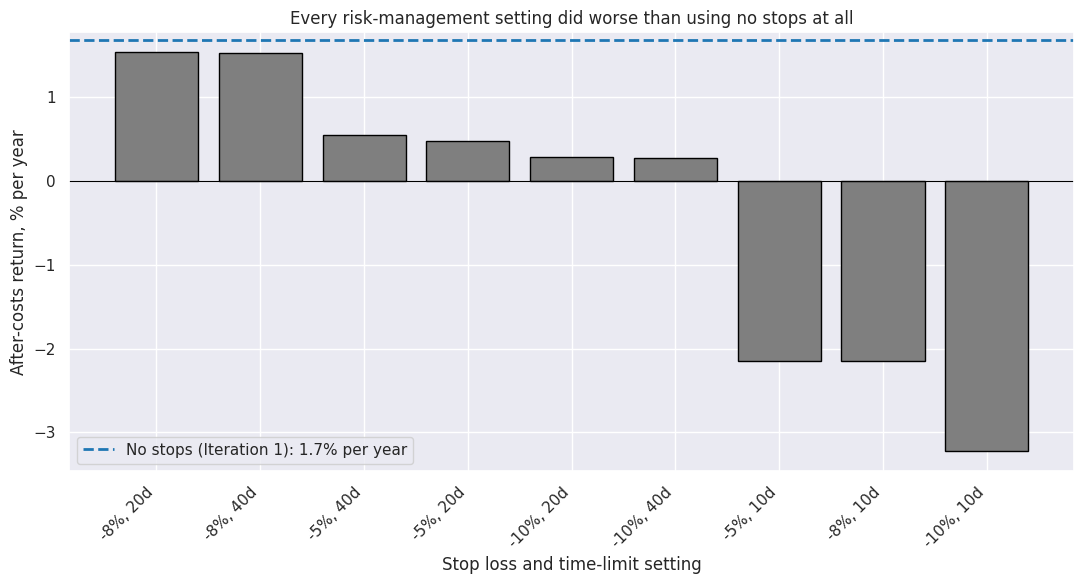

In [43]:
# --- Show the sweep as bars against the "no stops" reference line ---
# One bar per stop/time-limit setting, showing the after-costs yearly return.
# The dashed line is Iteration 1 (no risk management). Every bar below the line
# means that setting did WORSE than just leaving the system alone.

# Build a readable label for each of the nine settings.
grid['Setting'] = grid['Stop'] + ', ' + grid['Time Limit'].astype(str) + 'd'
grid_sorted = grid.sort_values('Costed CAGR', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(grid_sorted['Setting'], grid_sorted['Costed CAGR'],
              color='tab:gray', edgecolor='black')

# Reference line: Iteration 1, no stops, after costs.
ax.axhline(i1_costed_cagr, color='tab:blue', lw=2, ls='--',
           label=f'No stops (Iteration 1): {i1_costed_cagr:.1f}% per year')

ax.axhline(0, color='black', lw=0.8)   # zero line for orientation
ax.set_ylabel('After-costs return, % per year')
ax.set_xlabel('Stop loss and time-limit setting')
ax.set_title('Every risk-management setting did worse than using no stops at all')
ax.legend(loc='lower left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

First, what "after costs" means, because it is the only number worth reading. Every time the system buys or sells, it pays a small fee and loses a little to slippage, the gap between the price you hoped for and the price you actually got. The backtest measures the strategy two ways: once as if trading were free, and once charging these real costs. The free version is a fantasy. The after-costs version is what your account would actually have made, so that is what we judge on.

Now the chart. Yikes. Each grey bar is one of the nine settings we tried, three stop-loss levels crossed with three time limits. The height of the bar is how much that setting earned per year, after costs. The dashed blue line is Iteration 1, the system with no stops at all, which earned about 1.7% a year.

The result is the whole point of the section: every single bar sits below the blue line. Not one of the nine risk-management settings did as well as simply using no risk management. The best of them, an 8% stop with a 20-day limit, came closest but still fell short. Several settings, the ones with a short 10-day time limit, actually lost money, because cutting positions after only ten days sells them before a mean-reversion trade has any chance to work.

This is why we ran the whole grid instead of trusting the single baseline. One bad result could be a fluke of the two numbers we happened to pick. Nine bad results, across every sensible setting, is a pattern. On this strategy, adding stops and time limits does not have a hidden sweet spot waiting to be found. It makes the system worse no matter how we tune it.


Let's see this same chart with Sharpe ratios so we can see if any combinations improved the risk-return ratio.

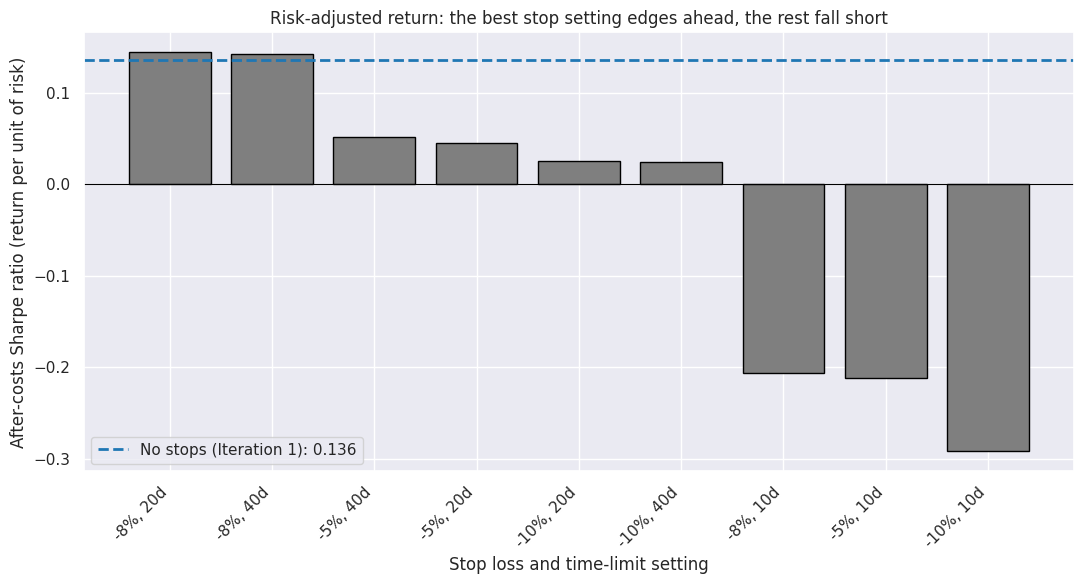

In [44]:
# --- Same chart, but Sharpe ratio instead of yearly return ---
# Sharpe measures return per unit of risk: how much you earned for how bumpy
# the ride was. Higher is better. Same nine settings, same reference line:
# Iteration 1 with no stops. A bar below the line means that setting gave a
# worse risk-adjusted result than using no risk management at all.
grid_sorted_sharpe = grid.sort_values('Costed Sharpe', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(grid_sorted_sharpe['Setting'], grid_sorted_sharpe['Costed Sharpe'],
       color='tab:gray', edgecolor='black')

ax.axhline(i1_costed_sharpe, color='tab:blue', lw=2, ls='--',
           label=f'No stops (Iteration 1): {i1_costed_sharpe:.3f}')

ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('After-costs Sharpe ratio (return per unit of risk)')
ax.set_xlabel('Stop loss and time-limit setting')
ax.set_title('Risk-adjusted return: the best stop setting edges ahead, the rest fall short')
ax.legend(loc='lower left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This chart changes the verdict slightly, and the change is the real lesson.

The Sharpe ratio measures return per unit of risk: how much you earned for how bumpy the ride was. A strategy can have a lower return but a higher Sharpe if it got that return more smoothly. So this is the fairer test of whether risk management earned its keep, because cutting losers is supposed to smooth the ride, not raise the return.

And here, two settings finally clear the line. Both 8% stops, at the 20-day and 40-day limits, edge above Iteration 1's risk-adjusted result. They are next to each other in the grid, the two mildest configurations, which matters: an edge that shows up in two adjacent settings is a little more believable than one that appears in a single isolated cell.

That is the trade in a single picture. Look at the two charts together:

- On return, every stop setting lost to no stops. Risk management cost upside.
- On risk-adjusted return, the two mildest stop settings won, barely. Risk management bought back a little smoothness.

This is what risk management almost always does. It is not free money and it rarely raises returns; it gives up some upside in exchange for a steadier, less punishing ride. Whether that trade is worth making depends on what you care about. An investor who cannot stomach deep drawdowns might happily take the 8% / 20-day version, accepting a lower return for a marginally better risk-adjusted profile. An investor focused purely on growth would skip the stops entirely. Neither is wrong, and the charts let each one see exactly what they are paying and getting.

The rest of the grid clears up nothing: the short 10-day limits are worse on both counts, and the -5% and -10% stops give back the edge. The improvement lives only in the two 8% settings, a narrow corner of a nine-cell grid. That is still thin ground. The forensics chapter would tell us that a benefit confined to two neighbouring settings, while better than a single lucky cell, is a long way from the broad plateau a result you can trust would show. The point is not that 8% / 20-day is a setting worth betting on. The point is that even the best the risk layer could do was trade real return for a marginal improvement in risk, and that is the honest shape of what stops and time

## Section 9: What Iteration 2 Tells Us

We set out to fix the open-ended losers in Iteration 1 by adding a stop loss and a time limit. We did fix them: the stop cut the XLE-type collapses, and the time limit released capital from positions that went nowhere. But fixing them did not produce a better system. After costs, every stop setting earned less than using no stops at all, and only at one narrow corner of the parameter grid did the risk layer improve the risk-adjusted return, and then only by a hair. That is the result, and it is worth sitting with rather than explaining away.

Two lessons carry out of this iteration, and they are the reason the chapter includes only one system of this kind:

1. A strategy built on a single technical indicator is hard to turn into a good system. The Bollinger entry is a real signal; deeply stretched prices do tend to revert, and the per-trade win rate proves it. But a real signal is not a real edge once costs, cash drag, and the occasional position that never reverts are accounted for. One indicator, however sound, rarely carries a whole system on its own.

2. Risk management is not free, and it does not always help. The instinct that adding a stop loss must improve a system is wrong. A stop has a cost: it sells positions that would have recovered, and on a mean-reversion strategy those are the very positions the edge depends on. What risk management typically buys is a smoother ride, not a higher return, and you pay for that smoothness in upside. Sometimes the trade is worth it and sometimes it is not, but it is always a trade.

None of this means stops and time limits are useless. It means they are tools with a cost, to be judged on evidence rather than assumed to help. On this strategy, the evidence says the cost outweighed the benefit almost everywhere we looked. A different strategy, a trend-following system rather than a mean-reversion one, would likely show the opposite, because a stop works with a trend-follower's edge instead of against it. The lesson is not "stops are bad." It is "test, do not assume."

We ran a small three-by-three grid here to make the point. A reader who wants to take this further can run a fuller search, and the process is the same one the spotting-bad-backtests chapter lays out. The goal is never to find the single best-scoring setting; it is to learn the shape of the surface and judge whether any apparent edge is robust or fragile.

The process, step by step:

1. Choose the parameters to vary and a sensible range for each. Here that would be the band lookback, the entry sigma, the exit band, the stop level, and the time limit. Keep the ranges realistic; sweeping a stop from 1% to 50% tests nothing useful.
2. Decide the scoring metric before you run, not after. Pick the measure you actually care about, after-costs return, Sharpe, Calmar, and commit to it, so you are not tempted to crown whichever setting happened to win on whichever metric flatters it.
3. Run every combination through the identical scoring path. Use the same harness, costs, and window for all of them, so the only thing that differs between cells is the parameters.
4. Plot the result as a surface, not a leaderboard. A heatmap or a set of bar charts shows the whole grid at once. Reading the shape is the point; reading only the top row is how people fool themselves.
5. Look for a plateau, not a peak. A setting you can trust sits in a broad region of settings that all behave similarly, so small changes in the parameters cause small changes in the result. A single high cell surrounded by poor ones is almost always overfitting, an accident of this particular history that will not repeat.
6. Confirm against the bad-backtest checks from Chapter 12. Test the result on a different but comparable universe, and across different sub-periods. An edge that survives only on this exact basket over this exact stretch is not an edge.

Run that process on this system and the conclusion will hold: there is no robust setting at which stops and time limits beat leaving the system alone on return, and the small risk-adjusted improvement lives in too narrow a corner to lean on. If a reader does find a setting that looks better, the right reaction is suspicion, not celebration. With enough combinations tried, something will always look good by chance, and telling the difference between a real edge and a lucky cell is the single most important skill this chapter teaches.

Iteration 3 turns to the other half of the system. So far every position has been sized the same, a flat twenty percent of capital regardless of how volatile the asset is. The next iteration sizes by volatility instead, giving less weight to the wild names and more to the steady ones, and asks whether shaping risk through position size, rather than through stops, does better at the trade-off this iteration laid bare.